# Overfitting

When constructing a model, we tune both the parameters and the model by fitting sample data. We then use the model and parameters to predict data we have not yet observed. We say a model is **overfit** when it is overly sensitive to noise and idiosyncrasies in the sample data, and therefore does not reflect the underlying data-generating process. To understand why this happens, one has to consider the amount of noise present in any dataset. One can consider a set of data as $D_T$, the true underlying data that came from whatever process we are trying to model, and $D = D_T + \epsilon$, some random noise. Because what we see is $D$, we might fit our model to very perfectly predict the given $D$, but not $D_T$.

This is problematic because we only care about fitting to the sample insofar as that gives us an accurate fit to future data. The two broad causes of overfitting are:

- Small sample size, so that noise and trend are not distinguishable
- Choosing an overly complex model, so that it ends up contorting to fit the noise in the sample


We can illustrate the concept of overfitting with the example of **Curve Fitting**

Overfitting becomes very clear when using **polynomial regression**.

Scenarios: We generate synthetic data that **noisily follows a quadratic** (degree 2) relationship.

**Model Comparisons**

- **Linear model (degree 1)** → **Underfits**  
  Simple linear regression cannot capture the curvature → poor fit

- **True underlying pattern** → Quadratic (degree 2)  
  Reasonable model, but still shows some residual error (because of noise)

- **High-degree polynomial (degree 9)** → **Severely overfits**  
  - Training error = **0** (perfectly interpolates all 10 points)  
  - But the curve has wild oscillations, especially at the tails  
  - This behavior will **not generalize** to new samples from the same distribution  
  → The model is fitting both the **signal** and the **noise** perfectly

**Conclusion**  
We have selected a model that is **far too complex** for the amount of data we have.

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import warnings
from statsmodels import regression
from scipy import stats
from matplotlib import pyplot as plt

# Silence futurewarnings
warnings.simplefilter(action="ignore", category=FutureWarning)

Let us generate the curves to illustrate overfitting

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_5125/3066132506.py:9: RankWarning: Polyfit may be poorly conditioned
  many = np.polyfit(x, y, 10)


Text(0.5, 1.0, 'Overfitting Example')

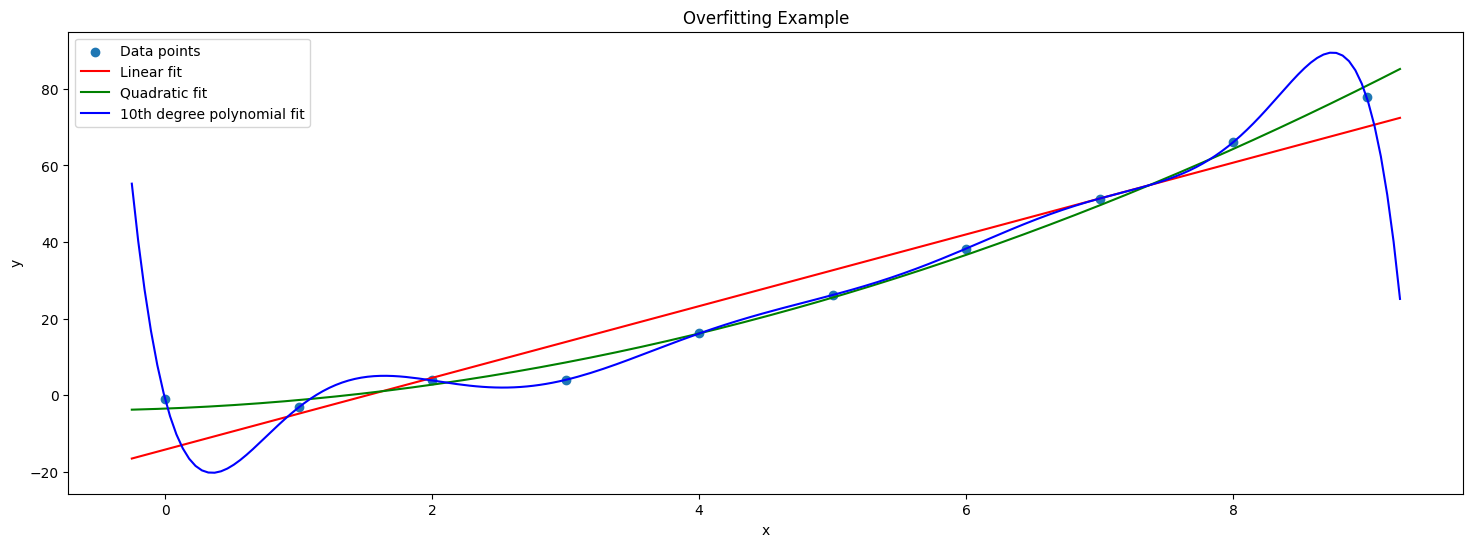

In [ ]:
# We first randomly generate some data that follows a quadratic relationship with some noise
x = np.arange(10)
y = x**2 + 2 * np.random.randn(10)

xs = np.linspace(-0.25, 9.25, 200)

# This is where we will define our fits. We will fit a linear, quadratic, and 10th degree polynomial to the data.
lin = np.polyfit(x, y, 1)
quad = np.polyfit(x, y, 2)
many = np.polyfit(x, y, 10)

# Plot the data and the fits
plt.figure(figsize=(18, 6))
plt.scatter(x, y, label='Data points')
plt.plot(xs, np.polyval(lin, xs), label='Linear fit', color='red')
plt.plot(xs, np.polyval(quad, xs), label='Quadratic fit', color='green')
plt.plot(xs, np.polyval(many, xs), label='10th degree polynomial fit', color='blue')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Overfitting Example')

When we work with real data, there is unlikely to ever be a situation where a 9th degree polynomial is appropriate. Our choice of function should reflect a belief about the underlying porcess and the real-world processes do not follow high-degree polynomial curves.

**Note: Model/Parameter Parsimony**

Just as the most elegant physics models describe a tremendous amount of our world through a few equations, a good trading model should explain most of the data through a few rules. Any time you start to have a number of rules even close to the number of points in your data set, you can be sure you are **overfitting**. Since **parameters** can be thought of as rules (as they equivalently constrain a model), the same is true of overfitting via too many parameters. **Fewer parameters is better**, and it is better to explain 60% of the data with 2–3 parameters than 90% with 10.

**Beware of the perfect fit**

Just because there is almost always noise present in real data, a **perfect fit** is almost always indicative of **overfitting**.

It is almost impossible to know the percentage noise/signal in a given data set while you are developing the model, but use your common sense. If the predictions **surprisingly good?** , then you are probably **overfitting**.

#### Example: Regression parameters

How do we know which variables to include in a model? If we are afraid of omitting something important, we might try different combinations and include all the variables we can find that improve the fit. Below we regress one asset that is in the same sector as the asset whose price we are trying to predict, and three other unrelated ones. In our initial timeframe, we are able to fit the model **more closely** to the data when using **multiple** variables than when using just one.

In [82]:
# Define our parameters and download the data. Here we will be using data for AAPL, PG, GOOGL, AMZN and COST from 2020 to 2021.
start_date = '2020-01-01'
end_date = '2021-12-31'

# Download our data from Yahoo Finance
x1 = yf.download('AAPL', start=start_date, end=end_date)['Close']
x2 = yf.download('PG', start=start_date, end=end_date)['Close']
x3 = yf.download('GOOGL', start=start_date, end=end_date)['Close']
x4 = yf.download('AMZN', start=start_date, end=end_date)['Close']
y = yf.download('COST', start=start_date, end=end_date)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


What we are trying to do is to predict the price of Costco (COST) based on the prices of AAPL, PG, GOOGL, and AMZN. We will use a linear regression model for this. Now, we know that PG is in a completely different industral sector as compared to the other stocks, and hence it would not be wise to give too much credence to AAPL, GOOGL, and AMZN share price when it comes to predicting COST. But over here, we will illustrate this example of overfitting.

In [83]:
# Define a function to compute the predicted values given a model and the independent variable(s)
def ols_predict(dependent_var, *independent_vars):
  if len(independent_vars) == 1:
    X = sm.add_constant(independent_vars[0])
  else:
    X = sm.add_constant(pd.concat(independent_vars, axis=1))
  model = regression.linear_model.OLS(dependent_var, X).fit()
  return model, model.predict(X)

In [84]:
# Run the simple linear regression using x1 as the independent variable
slr, slr_prediction = ols_predict(y, x1)

# Run the multiple linear regression using x1 to x4 as independent variables
mlr, mlr_prediction = ols_predict(y, x1, x2, x3, x4)

# Compute the adjusted R-Squared for both models
print(f"Simple Linear Regression Adjusted R-Squared: {slr.rsquared_adj:.4f}")
print(f"Simple Linear Regression p-value: {slr.f_pvalue}")
print(f"Multiple Linear Regression Adjusted R-Squared: {mlr.rsquared_adj:.4f}")
print(f"Multiple Linear Regression p-values: {mlr.f_pvalue}")

Simple Linear Regression Adjusted R-Squared: 0.7993
Simple Linear Regression p-value: 2.1120268792472525e-177
Multiple Linear Regression Adjusted R-Squared: 0.9212
Multiple Linear Regression p-values: 1.6115644446907074e-274


Let us visualise the plots for the regression model!

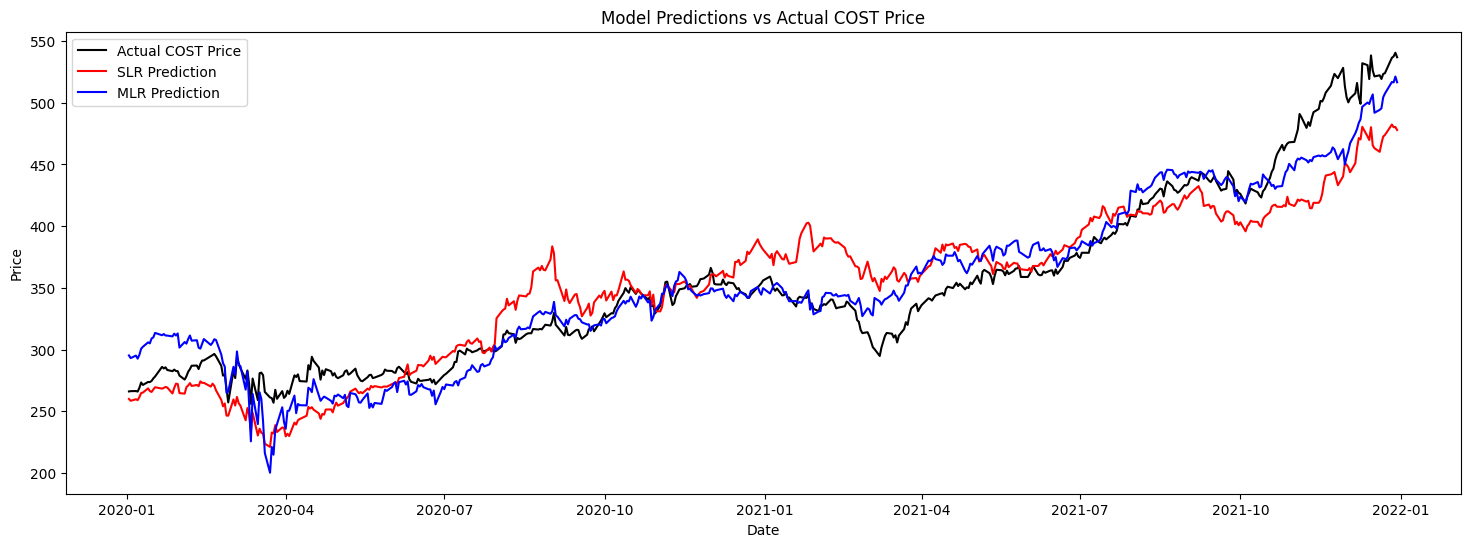

In [85]:
plt.figure(figsize=(18, 6))
plt.plot(y.index, y, label='Actual COST Price', color='black')
plt.plot(y.index, slr_prediction, label='SLR Prediction', color='red')
plt.plot(y.index, mlr_prediction, label='MLR Prediction', color='blue')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model Predictions vs Actual COST Price')
plt.show()

Looking at the R-squared values, we see that the MLR produced a better fit and predictive power as compared to the SLR. Now we might be tempted to use the MLR to predict the future price of COST given the other variables, but this is where the problem of overfitting comes in. We take the exact same parameters estimated from the original period and apply them to a **new, unseen time period**.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Simple Linear Regression R-Squared on new data: -0.8437
Multiple Linear Regression R-Squared on new data: -0.1333


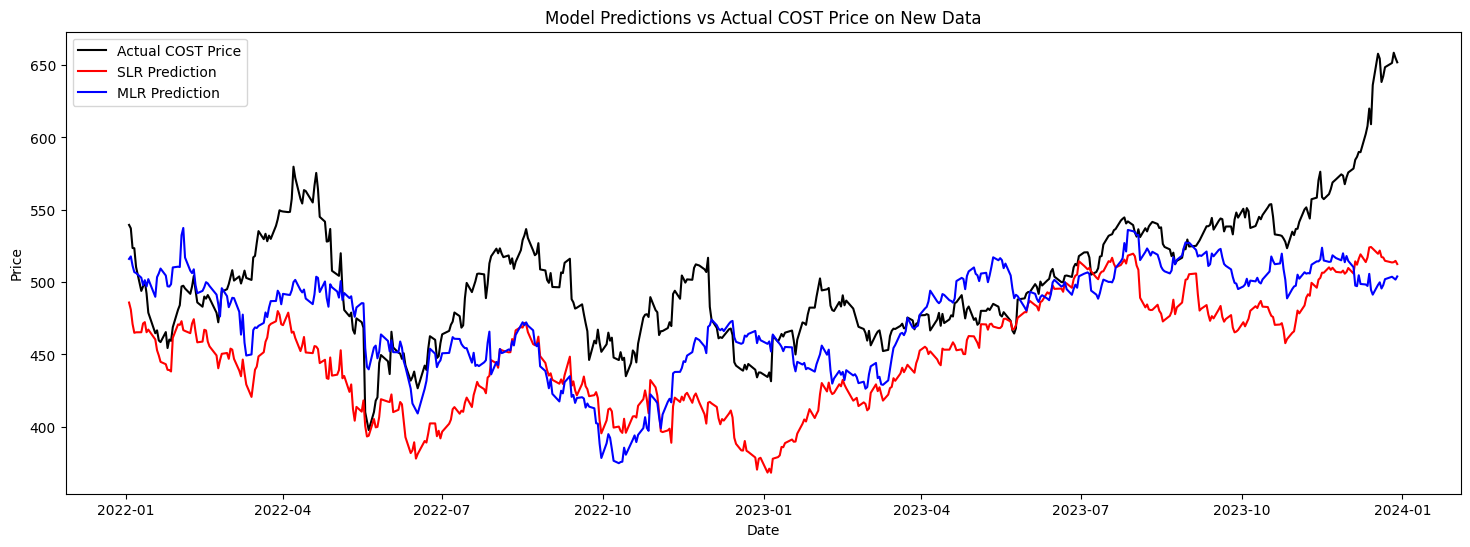

In [142]:
# Define our parameters and download the data. Here we will be using data for AAPL, PG, GOOGL, AMZN and COST from 2020 to 2021.
start_date = '2022-01-01'
end_date = '2023-12-31'

# Download our data from Yahoo Finance
x1 = yf.download('AAPL', start=start_date, end=end_date)['Close']
x2 = yf.download('PG', start=start_date, end=end_date)['Close']
x3 = yf.download('GOOGL', start=start_date, end=end_date)['Close']
x4 = yf.download('AMZN', start=start_date, end=end_date)['Close']
y = yf.download('COST', start=start_date, end=end_date)['Close']

#Extend our model to predict on the new data
X1 = sm.add_constant(x1)
X2 = sm.add_constant(pd.concat([x1, x2, x3, x4], axis=1))
slr_prediction_new = slr.predict(X1)
mlr_prediction_new = mlr.predict(X2)

slr_prediction_new = pd.DataFrame(slr_prediction_new, index=y.index)
mlr_prediction_new = pd.DataFrame(mlr_prediction_new, index=y.index)
slr_prediction_new.columns = ['SLR_Prediction']
mlr_prediction_new.columns = ['MLR_Prediction']


# Manually compute the R-Squared for both models on the new data
def r_squared(y_true, y_pred, dep_var_symbol, prediction_title):
  adj = float(len(y_true) - 1) / (len(y_true) - 5) # Compute adjustment factor
  SST = sum(((y_true - np.mean(y_true))**2)[dep_var_symbol]) # Total Sum of Squares
  SSE = sum(((np.array(y_true) - y_pred)**2)[prediction_title]) # Sum of Squared Errors
  return 1 - (SSE / SST) * adj
  
print(f"Simple Linear Regression R-Squared on new data: {r_squared(y, slr_prediction_new, 'COST', 'SLR_Prediction'):.4f}")
print(f"Multiple Linear Regression R-Squared on new data: {r_squared(y, mlr_prediction_new, 'COST', 'MLR_Prediction'):.4f}")

# Plot the predictions on the new data
plt.figure(figsize=(18, 6))
plt.plot(y.index, y, label='Actual COST Price', color='black')
plt.plot(y.index, slr_prediction_new, label='SLR Prediction', color='red')
plt.plot(y.index, mlr_prediction_new, label='MLR Prediction', color='blue')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model Predictions vs Actual COST Price on New Data')
plt.show()

**Results:**

- **Single-variable model** (sensible, related asset)  
  → Fit is **worse** than in-sample, but still provides some predictive value.

- **Multiple-variable model** (including unrelated assets)  
  → Fit is **dramatically worse** — essentially **useless** for prediction.

**Conclusion**  
The impressive in-sample fit of the multi-variable model was **not capturing true, persistent relationships**.  
Instead, it captured **spurious correlations** and **noise specific to the training period**.

**Lesson**  
- Great in-sample performance + poor out-of-sample performance = **overfitting**  
- Stable, useful models maintain reasonable performance across different time periods.

#### Example: Rolling Windows

One of the challenges in building a model that uses **rolling parameter estimates** — such as rolling mean, rolling beta, rolling volatility, etc. — is choosing the **window length** (number of observations).

- A **longer window**:
  - Captures longer-term trends
  - Produces estimates that are **less volatile** (smoother)
  - But **lags more** when new data arrives → slower to adapt to changes

- A **shorter window**:
  - Reacts quickly to new information
  - But estimates become **more noisy** and volatile

The choice of window length strongly affects how the rolling parameter estimate behaves and can change how we see and treat the data.

Below we calculate the **rolling averages** of a stock price for **different window lengths** and demonstrate how the choice of window length affects the resulting series.

[*********************100%***********************]  1 of 1 completed


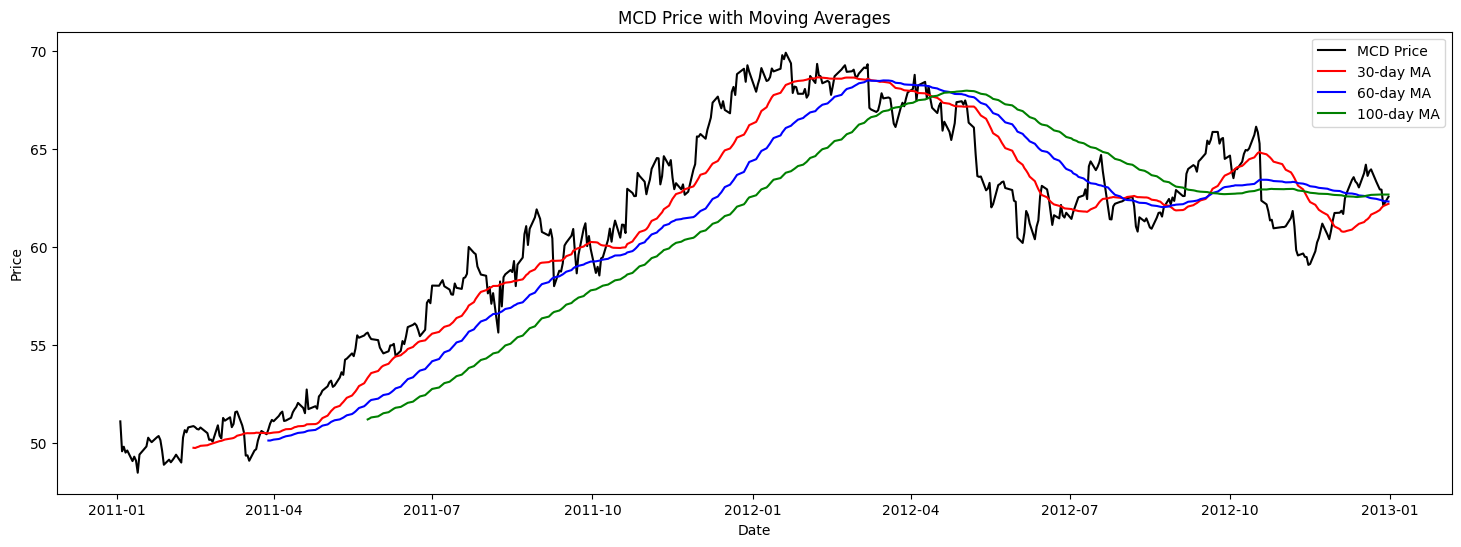

In [164]:
start_date = '2011-01-01'
end_date = '2013-01-01'

price_df = yf.download('MCD', start=start_date, end=end_date)['Close']

# Compute the 30, 60 and 100 day moving averages
price_df = pd.DataFrame(price_df)
price_df.columns = ['Close']
price_df['MA30'] = price_df['Close'].rolling(window=30).mean()
price_df['MA60'] = price_df['Close'].rolling(window=60).mean()
price_df['MA100'] = price_df['Close'].rolling(window=100).mean()

# Plot the asset price data with the moving averages
plt.figure(figsize=(18, 6))
plt.plot(price_df.index, price_df['Close'], label='MCD Price', color='black')
plt.plot(price_df.index, price_df['MA30'], label='30-day MA', color='red')
plt.plot(price_df.index, price_df['MA60'], label='60-day MA', color='blue')
plt.plot(price_df.index, price_df['MA100'], label='100-day MA', color='green')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('MCD Price with Moving Averages')
plt.show()

If we pick the window length based on which seems **best** — say, on how well our model or algorithm **performs** — we are **overfitting**. Below we have a simple **trading algorithm** which bets on the stock price **reverting to the rolling mean** (for more details, check out the **mean reversion notebook**).

We use the **performance** of this algorithm to score different window lengths and find the "best" one. **However**, when we consider a **different timeframe**, this "optimal" window length is **far from optimal**.

**Why?**... because our original choice was **overfitted to the sample data** — it captured noise and idiosyncrasies specific to that particular historical period rather than a generally useful, stable parameter.

In [165]:
# Function that trades using the mean reversion strategy based on the moving averages
def trade(stock, length):
  if length == 0:
    return 0
  mu = stock.rolling(window=length).mean()
  sigma = stock.rolling(window=length).std()
  z_score = (stock - mu) / sigma
  
  # Start with no money and shares
  money = 0
  count = 0
  for i in range(len(stock)):
    # Sell short if the z-score is > 1
    if z_score[i] > 1:
      money += stock[i]
      count -= 1
    # Long if the z-score is < -1
    elif z_score[i] < -1:
      money -= stock[i]
      count += 1
    # Clear position if the z-score is between -0.5 and 0.5
    elif abs(z_score[i]) < 0.5:
      money += count * stock[i]
      count = 0
  return money

In [166]:
# Find the window length between 0 and 252 that gives the best return
length_scores = [trade(price_df['Close'], length) for length in range(1, 253)]
best_length = np.argmax(length_scores) + 1
print(f"Best window length: {best_length} with return: {length_scores[best_length - 1]:.2f}")

Best window length: 11 with return: 780.88


The example above shows us that window length 13 yielded the best return among all possible window lengths. But this does not mean we should use this value, as we only sampled once in the sample space. By testing on the future data, we get the following alternative results instead for max return.

In [167]:
start_2 = '2013-01-01'
end_2 = '2015-01-01'

price_df_2 = yf.download('MCD', start=start_2, end=end_2)['Close']
price_df_2 = pd.DataFrame(price_df_2)
price_df_2.columns = ['Close']

length_scores2 = [trade(price_df_2['Close'], length) for length in range(1, 253)]

# Compare what we would think is the best window length based on the first data set to the returns we get on the second data set
print(f"Return on second data set using best window length {best_length} from first data set: {length_scores2[best_length - 1]:.2f}")
print(f"Best window length on second data set: {np.argmax(length_scores2) + 1} with return: {max(length_scores2):.2f}")


[*********************100%***********************]  1 of 1 completed


Return on second data set using best window length 11 from first data set: 17.17
Best window length on second data set: 141 with return: 302.30


As you can see, our best window length is clearly different from the initial window length that we derived from our test data, when we actually ran it on the new forward looking dataset. Clearly fitting our sample data does not always give us good results in the future, and for exploratory purposes, we will plot the length scores computed from both timeframes.

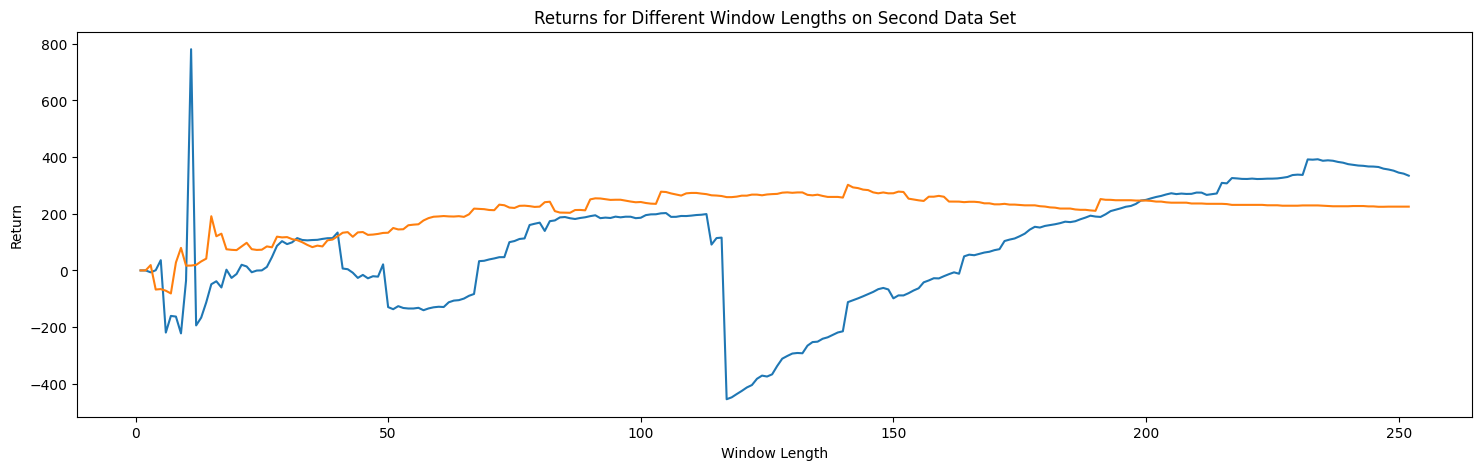

In [169]:
plt.figure(figsize=(18, 5))
plt.plot(range(1, 253), length_scores)
plt.plot(range(1, 253), length_scores2)
plt.xlabel('Window Length')
plt.ylabel('Return')
plt.title('Returns for Different Window Lengths on Second Data Set')
plt.show()

Remark on Window Length Distribution

--- 

The blue region represents in-sample (training) performance across different window lengths. Notice how small window lengths are extremely noisy. For example, the 11-day window produces abnormally large returns, while neighboring windows (10 or 12 days) generate significant losses.

This sharp spike is a classic sign of **overfitting** — the strategy becomes highly sensitive to small parameter changes and lacks robustness.

Instead of choosing the window with the highest return, we should select a **stable region** where performance remains reasonably consistent even if the window length shifts. A slightly lower but flatter region is preferable because it indicates robustness to changing market conditions.

This is confirmed in the out-of-sample test: while another window (e.g., 190 days) may perform best, selecting a robust region still yields solid performance. In contrast, choosing spurious peaks from the training data typically leads to poor generalization.